In [13]:
from typing import Iterable
from copy import deepcopy
from itertools import product
from pathlib import Path 

from qnldraw import shapes, paths, components, Angle, Params 
from qnldraw.shapes import Rectangle
from qnldraw.paths import Trace

import qnldraw as qd
import qnldraw.junction as qj 
import ruamel.yaml as yaml 
import numpy as np 

import gdspy
import os 

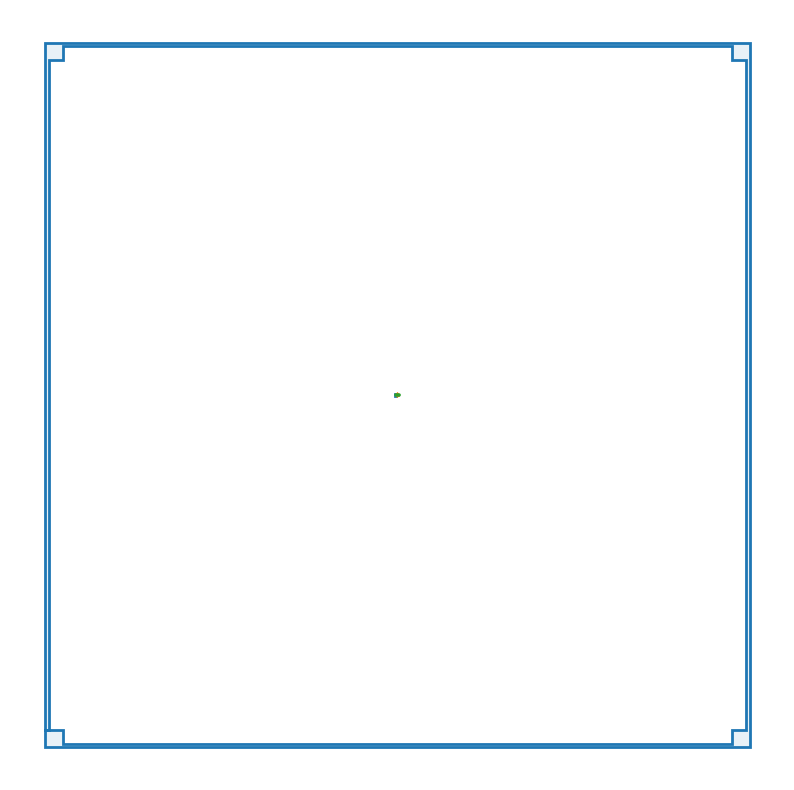

In [35]:
def load_params(filename):
    with open(filename, 'r') as file:
        params = yaml.load(file, Loader=yaml.Loader)
    return params

def junction_leads_bandages(params): 
    params = Params(params)

    chip = qd.Chip()

    # layout parameters 
    pad_spacing = params['pad_spacing']
    lead_separation = np.sqrt(params['squid_loop_area'])
    lead_v_separation = lead_separation
    lead_h_separation = lead_separation

    hdlayer = params['layers.highdose']
    ldlayer = params['layers.lowdose']

    # junction leads and bandages 
    lead_params = params['leads']
    lead_params.update({ 
        'total_length': (pad_spacing - lead_h_separation)/2 + params['bandages']['lead_overlap'], 
        'extension': (lead_params['inner.width'] - params['wire.width'])/2
    })

    leads = qj.JunctionLead(**lead_params)
    bandage = qj.Bandage(**params['bandages'])

    lx = pad_spacing/2 + lead_params['pad_overlap']
    ly = params['wire']['width'] + lead_v_separation/2

    left_lead = leads.place((-lx/2, 0))
    right_lead = leads.place((lx/2, 0), mirror='y')

    left_bandage = bandage.attach(left_lead, 'origin', 'right', offset=(params['bandages.lead_overlap'], 0))
    right_bandage = bandage.attach(left_lead, 'origin', 'left', offset=(-params['bandages.lead_overlap'], 0))

    chip.add_component([left_bandage, right_bandage], 'bandages', layers=params['bandages.layer'])
    chip.add_component([left_lead, right_lead], 'leads', layers=hdlayer)

    lead_lowdose = qd.offset(
        [left_lead, right_lead],
        params['leads.undercut'],
        join_first=True,
        join='round',
        tolerance=1
    )

    chip.add_component(lead_lowdose, cid='lowdose', layers=ldlayer)

    

    return chip 


param_file = 'FD4/snail.yaml'
params = load_params(param_file)

chip =junction_leads_bandages(params)
mask = chip.render('mask', draw_border=True)

fig = qd.plot(mask[0], figsize=(10,10), axis=False)
lib = gdspy.GdsLibrary()
lib.write_gds('chip1.gds', cells=mask)